#### Stein Variational Gradient Descent
+ This notebook is for Stein Variational Inference:
+ target posterior $p(w|x^n)$ is approximated by $q(w)$ based on Stein Discrepancy $D(p, q)$:
$$
D(p, q) := \max_{\phi \in F} E_{w \sim q} [tr(A_{p}\phi(w))],
$$
+ where $A_p$ is stein's operator: $A_{p} \phi(w) = \nabla_w \log p^T(w|x^n) \phi(w) + \nabla_w \phi(w)$.
+ When $F$ is RKHS on $d$-dimensional, and the approximated distribution is $q(z)$, where $z = T(x) = x + \epsilon \phi(x)$,
+ then the the maximum direction $\phi^*_{q,p}$ of $\frac{d}{d\epsilon}KL(q|p) |_{\epsilon=0}$ is given by 
$$
\phi^*_{q,p}(\cdot) = E_{w \sim q} [tr(A_p k(w,\cdot))] \approx \sum_{l=1}^L \frac{1}{L} \Bigl\{ \nabla_w \log p(w_l|x^n) k(w_l,\cdot) + \nabla_w k(w_l, \cdot) \Bigr\}
$$

+ Based on the value, the sample of the posterior distribution $w^{(l)}$ is calculated iteratively:
$$
w^{(l+1)} = w^{(l)} + \epsilon \phi^*{q,p}(w^{(l)})
$$
+ where $\epsilon$ is step size, and should be gradually descreased like conventional gradient descent method.

In [2]:
%matplotlib inline

In [3]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

In [4]:
def rot_x(theta: float) -> np.ndarray:
    return np.array([
        [1, 0, 0],
        [0, np.cos(theta), -np.sin(theta)],
        [0, np.sin(theta), np.cos(theta)],
    ])

def rot_y(theta: float) -> np.ndarray:
    return np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0, 1, 0],
        [-np.sin(theta), 0, np.cos(theta)],
    ])

def rot_z(theta: float) -> np.ndarray:
    return np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1],
    ])


In [5]:
def dt_rot_x(theta: float) -> np.ndarray:
    return np.array([
        [0, 0, 0],
        [0, -np.sin(theta), -np.cos(theta)],
        [0, np.cos(theta), -np.sin(theta)],
    ])

def dt_rot_y(theta: float) -> np.ndarray:
    return np.array([
        [-np.sin(theta), 0, np.cos(theta)],
        [0, 0, 0],
        [-np.cos(theta), 0, -np.sin(theta)],
    ])

def dt_rot_z(theta: float) -> np.ndarray:
    return np.array([
        [-np.sin(theta), -np.cos(theta), 0],
        [np.cos(theta), -np.sin(theta), 0],
        [0, 0, 0],
    ])



# First step
+ Check rotational gradient

In [38]:
thetas = np.random.normal(size=3)

In [74]:
thetas = [np.pi/5, np.pi/2, np.pi*1.2]

In [76]:
cz, sz = np.cos(thetas[0]), np.sin(thetas[0])
cy, sy = np.cos(thetas[1]), np.sin(thetas[1])
cx, sx = np.cos(thetas[2]), np.sin(thetas[2])

In [88]:
test1 = rot_z(thetas[0]) @ rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [cy*cz, -cx*sz+sx*sy*cz, sx*sz+cx*sy*cz],
    [cy*sz, cx*cz+sx*sy*sz, -sx*cz+cx*sy*sz],
    [-sy, sx*cy, cx*cy],
])

np.allclose(test1, test2)

True

In [92]:
test1 = rot_z(thetas[0]) @ rot_y(thetas[1]) @ dt_rot_x(thetas[2])

test2 = np.array([
    [0, sx*sz+cx*sy*cz, cx*sz-sx*sy*cz],
    [0, -sx*cz+cx*sy*sz, -cx*cz-sx*sy*sz],
    [0, cx*cy, -sx*cy],
])

np.allclose(test1, test2)

True

In [94]:
test2

array([[ 0.00000000e+00, -1.00000000e+00, -1.11022302e-16],
       [ 0.00000000e+00, -1.11022302e-16,  1.00000000e+00],
       [ 0.00000000e+00, -4.95380036e-17,  3.59914664e-17]])

In [82]:
test1 = rot_z(thetas[0]) @ dt_rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [-sy*cz, sx*cy*cz, cx*cy*cz],
    [-sy*sz, sx*cy*sz, cx*cy*sz],
    [-cy, -sx*sy, -cx*sy],
])

np.allclose(test1, test2)

True

In [84]:
test1 = dt_rot_z(thetas[0]) @ rot_y(thetas[1]) @ rot_x(thetas[2])

test2 = np.array([
    [-cy*sz, -cx*cz-sx*sy*sz, sx*cz-cx*sy*sz],
    [cy*cz, -cx*sz+sx*sy*cz, sx*sz+cx*sy*cz],
    [0, 0, 0],
])

np.allclose(test1, test2)

True

In [86]:
test2

array([[-3.59914664e-17,  1.00000000e+00,  1.11022302e-16],
       [ 4.95380036e-17,  1.11022302e-16, -1.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

# Next Step
+ Check algorithm by rigid transformation
+ $p(y|x,w) = N(y|Rx + t, I_M)$, and $R, t$ is learnable paramters

## Data Generation

In [137]:
## dimension of input
M = 3

# number of samples
n = 50

data_seed = 20250108
np.random.seed(data_seed)

true_trans = np.array([5, -5, 5])
# true_mu = np.array([-10, 10])
# true_xyz_theta = np.array([np.pi/6, np.pi/2, -np.pi/4])
true_xyz_theta = np.array([np.pi/5, np.pi/2, np.pi*1.2])
true_rot = rot_z(true_xyz_theta[2]) @ rot_y(true_xyz_theta[1]) @ rot_x(true_xyz_theta[0])

train_X = np.random.normal(size=(n, M))
train_Y = train_X @ true_rot.T + true_trans + 0.1 * np.random.normal(size=(n, M))

In [139]:
true_rot

array([[-4.95380036e-17, -9.83623360e-17, -1.00000000e+00],
       [-3.59914664e-17, -1.00000000e+00,  1.02478896e-16],
       [-1.00000000e+00,  3.59914664e-17,  4.95380036e-17]])

## Hyperparameters
+ kernel function: modified Radial Basis Kernel $\exp(-\frac{1}{2h^2} \sum_k (t_k - t_k')^2) \times \exp(-\frac{1}{2h^2} \sum_k (\arctan2 (\sin(\theta_k - \theta'_k), \cos(\theta_k - \theta'_k))^2)$
+ prior: multivariate distribution and von mises distribution $\prod_k N(t_k|0, \beta^{-1}) \prod_k vonmises(\theta_k|0, \kappa)$
+ initial samples: $w \sim q_0(w)$, where $w \in R^{L \times M}$, $L$ is the number of sample from the approximated posterior

In [142]:
ln_seed = 20241231
np.random.seed(ln_seed)

pri_beta = 1
pri_kappa = 1

L = 100
initial_post_param = np.hstack([
    np.random.normal(size=(L, 3)),
    np.random.vonmises(0, 1, size=(L, 3)),
])

h = 1
first_step_size = 0.05

## Learning

In [145]:
n_ite = 500
post_param = initial_post_param.copy()

disp_cycle = 50

alpha = 0.9
# step_size = 1e-2
jitter = 1e-6
r_t = 0

for ite in range(n_ite):
    diff_param = post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]
    diff_trans = diff_param[:,:,:3]
    diff_theta = diff_param[:,:,3:]
    
    dist = (diff_trans ** 2).sum(axis=2) + (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) ** 2).sum(axis = 2)
    
    h = 0.5*np.median(dist[np.triu_indices(L, k=1)])**2/np.log(L)
    
    kernel_post = np.exp(-dist/(2*h**2))
    
    dw_kernel_post = np.hstack([
        (diff_trans * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
        (np.arctan2(np.sin(diff_theta), np.cos(diff_theta)) * kernel_post[:,:,np.newaxis]).sum(axis=0) / (h**2),
    ])
    
    rot_x_post = [rot_x(theta) for theta in post_param[:,3]]
    rot_y_post = [rot_y(theta) for theta in post_param[:,4]]
    rot_z_post = [rot_z(theta) for theta in post_param[:,5]]
    post_trans = post_param[:,:3]
    
    rots_x = np.array([rotz@roty@rotx@train_X.sum(axis=0)  for rotz, roty, rotx in zip(rot_z_post, rot_y_post, rot_x_post)])
    dtrans_logp = train_Y.sum(axis=0)[np.newaxis,:] - n*post_trans - rots_x - pri_beta/2*post_trans
    
    cov_YX = train_Y.T @ train_X
    sum_X = train_X.sum(axis=0)
    dtheta_z_logp = np.array([
        np.trace((dt_rot_z(theta_z) @ roty @ rotx).T @ cov_YX) 
        - trans_vec @ dt_rot_z(theta_z) @ roty @ rotx @ sum_X
        for theta_z, roty, rotx, trans_vec in zip(post_param[:,5], rot_y_post, rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,5])
    
    dtheta_y_logp = np.array([
        np.trace((rotz @ dt_rot_y(theta_y) @ rotx).T @ cov_YX) 
        - trans_vec @ rotz @ dt_rot_y(theta_y) @ rotx @ sum_X
        for rotz, theta_y, rotx, trans_vec in zip(rot_z_post, post_param[:,4], rot_x_post, post_trans)
    ]) - pri_kappa * np.sin(post_param[:,4])
    
    dtheta_x_logp = np.array([
        np.trace((rotz @ roty @ dt_rot_x(theta_x)).T @ cov_YX) 
        - trans_vec @ rotz @ roty @ dt_rot_x(theta_x) @ sum_X
        for rotz, roty, theta_x, trans_vec in zip(rot_z_post, rot_y_post, post_param[:,3], post_trans)
    ]) - pri_kappa * np.sin(post_param[:,3])
    
    dw_logp = np.block([
        dtrans_logp, dtheta_x_logp[:,np.newaxis], dtheta_y_logp[:,np.newaxis], dtheta_z_logp[:,np.newaxis]
    ])
    
    # gradient of target functional
    phi_post_param = (kernel_post.T @ dw_logp + dw_kernel_post) / L
    
    # sample update
    if ite == 0:
        r_t = phi_post_param**2
    else:    
        r_t = alpha * r_t + (1 - alpha) * phi_post_param**2
    
    # step_size = first_step_size / (ite + 1)
    # step_size = first_step_size
    step_size = first_step_size / np.sqrt(r_t + jitter)
    post_param = post_param + step_size * phi_post_param

    # calc stein discrepancy
    dw_partial_kernel = -1/h**2 * (post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:]) * kernel_post[:,:,np.newaxis]
    dwdw_kernel = (1/h**2 * kernel_post[:,:,np.newaxis] * (1+(post_param[np.newaxis,:,:] - post_param[:,np.newaxis,:])**2 / (2*h**2) ))
    # divergence of phi
    div_phi = (dw_logp[np.newaxis,:,:] * dw_partial_kernel + dwdw_kernel).sum(axis=2).mean()
    dw_logp_phi = (dw_logp * phi_post_param).sum(axis=1).mean()
    stein_discrepancy = dw_logp_phi + div_phi
    
    if ite % disp_cycle == 0:
        print("ite = {}, post_param = {}, h = {}, step_size = {}, stein_discrepancy = {}".format(ite, post_param[0], h, step_size[0], stein_discrepancy))

ite = 0, post_param = [-0.48587376 -0.67252822 -0.24739504 -0.65844139 -0.74739654 -1.58012186], h = 17.00867945920435, step_size = [0.00020093 0.00020565 0.00019608 0.0910573  0.0013198  0.00461047], stein_discrepancy = 190239.49977925498
ite = 50, post_param = [ 1.79001886 -2.94694521  2.02921413 -1.96727231  0.48360997 -0.01068349], h = 16.563260190188174, step_size = [0.00032083 0.00032927 0.0003127  0.05526531 0.00780469 0.01526897], stein_discrepancy = 55418.07982112625
ite = 100, post_param = [ 3.75865852 -4.89621502  4.00981112 -2.46448004  0.82521124  0.31045038], h = 14.046767661778423, step_size = [0.00089282 0.00094516 0.00085335 0.02849849 0.03371141 0.02877202], stein_discrepancy = 4180.565081125898
ite = 150, post_param = [ 4.50600401 -5.54180837  4.77642372 -2.81105281  1.06687726  0.31675865], h = 10.709539358004195, step_size = [0.00882195 0.00976023 0.00825864 0.02170919 0.0299493  0.02145284], stein_discrepancy = 80.91974375731867
ite = 200, post_param = [ 4.9355322

In [147]:
true_trans, true_xyz_theta

(array([ 5, -5,  5]), array([0.62831853, 1.57079633, 3.76991118]))

In [149]:
np.array([
    rot_z(theta_z) @ rot_y(theta_y) @ rot_x(theta_x)
    for theta_z, theta_y, theta_x in zip(post_param[:,5], post_param[:,4], post_param[:,3])
]).mean(axis=0)

array([[-1.17865531e-03, -6.41640062e-02, -9.90518953e-01],
       [-1.57561224e-04, -9.89787180e-01,  6.41037375e-02],
       [-9.94660945e-01,  5.70224573e-04,  2.11539120e-03]])

In [151]:
true_rot

array([[-4.95380036e-17, -9.83623360e-17, -1.00000000e+00],
       [-3.59914664e-17, -1.00000000e+00,  1.02478896e-16],
       [-1.00000000e+00,  3.59914664e-17,  4.95380036e-17]])

In [157]:
post_param[:,:3].mean(axis=0)

array([ 4.97459223, -4.93339696,  4.9411948 ])

In [114]:
rot_z(post_param[0,5]) @ rot_y(post_param[0,4]) @ rot_x(post_param[0,3])

array([[ 0.14158817, -0.22349203, -0.9643672 ],
       [-0.08950537, -0.9730815 ,  0.21237041],
       [-0.98587097,  0.0562469 , -0.15778057]])

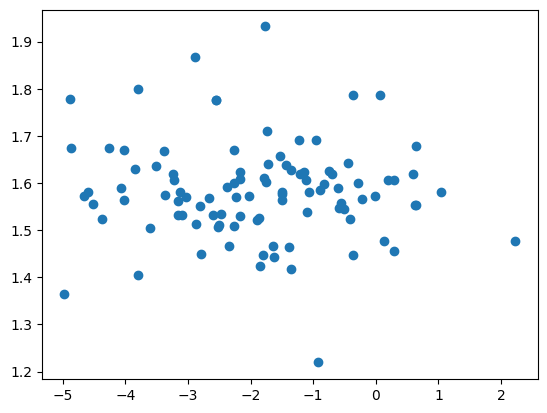

In [153]:
plt.scatter(post_param[:,3], post_param[:,4])
plt.show()

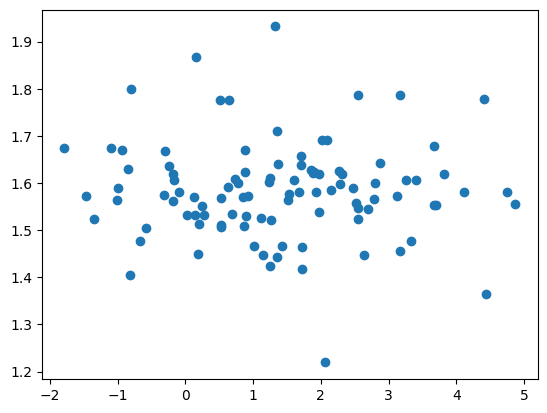

In [155]:
plt.scatter(post_param[:,5], post_param[:,4])
plt.show()